In [1]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import statsmodels.api as sm

In [6]:
import random
#Generate random sample with 5 features/variables, 200 datasets
N = 200

# Generate X: 200 samples, each with 5 features
X = [[random.gauss(0, 1) for _ in range(5)] for _ in range(N)]

# Generate y: 200 samples, each with 1 target value
y = [[random.gauss(0, 1)] for _ in range(N)]

y_logistic = np.random.randint(0, 2, size=200)

# Optional: print first 3 samples to check
print("X:", X[:3])
print("y:", y[:3])

X: [[0.6658064216613293, -2.1268041985057096, 0.7231778678918495, 2.1498285455475434, 0.3351011907787146], [0.7034087433937574, 0.39488701256201525, -0.049387650970222845, 0.06976584326730552, 0.3590377297515748], [-0.2288078396096364, 1.9693891094881113, 0.08115401717907623, -1.4886811415017969, -1.6800209562391564]]
y: [[-1.6385646795628295], [0.4837862180701656], [0.4991041964480022]]


In [7]:
#Linear Regression: 
X = sm.add_constant(X, has_constant='add')
model1 = sm.OLS(y, X).fit()
model1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.027
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     1.060
Date:                Sat, 04 Apr 2026   Prob (F-statistic):              0.384
Time:                        11:58:25   Log-Likelihood:                -263.89
No. Observations:                 200   AIC:                             539.8
Df Residuals:                     194   BIC:                             559.6
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0186      0.066      0.280      0.780      -0.112       0.149
x1            -0.0649      0.071     -0.916      0.361      -0.204       0.075
x2             0.1125      0.067      1.689      0.093      -0.019       0.244
x3            -0.0054      0.067     -0.080      0.936      -0.138       0.128
x4            -0.0295      0.066     -0.444      0.657      -0.160       0.102
x5             0.0821      0.065      1.256      0.211      -0.047       0.211
==============================================================================
Omnibus:                        1.303   Durbin-Watson:                   1.890
Prob(Omnibus):                  0.521   Jarque-Bera (JB):                1.367
Skew:                          -0.139   Prob(JB):                        0.505
Kurtosis:                       2.706   Cond. No.                         1.28
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [8]:
model2 = sm.Logit(y_logistic, X).fit()
model1.summary()

Optimization terminated successfully.
         Current function value: 0.684912
         Iterations 4


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.027
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     1.060
Date:                Sat, 04 Apr 2026   Prob (F-statistic):              0.384
Time:                        11:58:32   Log-Likelihood:                -263.89
No. Observations:                 200   AIC:                             539.8
Df Residuals:                     194   BIC:                             559.6
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0186      0.066      0.280      0.780      -0.112       0.149
x1            -0.0649      0.071     -0.916      0.361      -0.204       0.075
x2             0.1125      0.067      1.689      0.093      -0.019       0.244
x3            -0.0054      0.067     -0.080      0.936      -0.138       0.128
x4            -0.0295      0.066     -0.444      0.657      -0.160       0.102
x5             0.0821      0.065      1.256      0.211      -0.047       0.211
==============================================================================
Omnibus:                        1.303   Durbin-Watson:                   1.890
Prob(Omnibus):                  0.521   Jarque-Bera (JB):                1.367
Skew:                          -0.139   Prob(JB):                        0.505
Kurtosis:                       2.706   Cond. No.                         1.28
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [20]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import mean_squared_error

#ridge
ridge_model = Ridge(alpha=1.0)  # cross_validation to find best alpha
ridge_model.fit(X, y)
ridge_pred = ridge_model.predict(X)
ridge_mse = mean_squared_error(y, ridge_pred)
print("Ridge Regression MSE:", ridge_mse)
print("Ridge Coefficients:", ridge_model.coef_)


Ridge Regression MSE: 0.8195725527096789
Ridge Coefficients: [ 0.         -0.06444663  0.11184429 -0.00545132 -0.02926766  0.08172689]


Best alpha from cross-validation: 100000
Corresponding MSE: 0.8599708229437176


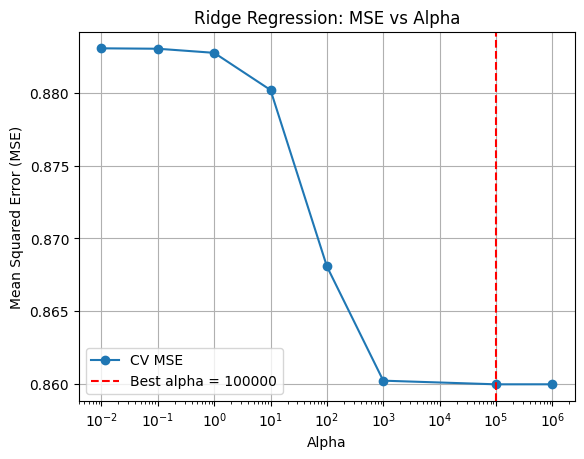

In [19]:
#CV for alpha example:
from sklearn.model_selection import cross_val_score
alphas = [0.01, 0.1, 1.0, 10.0, 100.0, 1000, 100000, 1000000]

mse_list = []

for alpha in alphas:
    model = Ridge(alpha=alpha)
    # cross_val_score returns negative MSE, so we take negative to get positive MSE
    scores = cross_val_score(model, X, y, cv=5, scoring='neg_mean_squared_error')
    mse_list.append(-np.mean(scores))

#Find the best alpha
best_index = np.argmin(mse_list)
best_alpha = alphas[best_index]
print("Best alpha from cross-validation:", best_alpha)
print("Corresponding MSE:", mse_list[best_index])

#Plot alpha vs MSE
plt.plot(alphas, mse_list, marker='o', label='CV MSE')
plt.xscale('log')
plt.xlabel('Alpha')
plt.ylabel('Mean Squared Error (MSE)')
plt.title('Ridge Regression: MSE vs Alpha')
plt.axvline(best_alpha, color='red', linestyle='--', label=f'Best alpha = {best_alpha}')
plt.legend()
plt.grid(True)
plt.show()

In [11]:

lasso_model = Lasso(alpha=0.1)  # smaller alpha usually better for small dataset
lasso_model.fit(X, y)
lasso_pred = lasso_model.predict(X)
lasso_mse = mean_squared_error(y, lasso_pred)
print("Lasso Regression MSE:", lasso_mse)
print("Lasso Coefficients:", lasso_model.coef_)

Lasso Regression MSE: 0.8412502775376223
Lasso Coefficients: [ 0.         -0.          0.00345488 -0.         -0.          0.        ]
